# Electrostatic Potential of Water from MBIS Atomic Multipoles

This example demonstrates the FFprime multipole electrostatics workflow:

1. Load a molecular structure and derive **MBIS** (Minimal Basis Iterative
   Stockholder) atomic multipoles.
2. Build a **multipole expansion** (monopole, dipole, quadrupole) of the
   molecular charge density.
3. Evaluate the resulting electrostatic potential on a grid and compare it
   against a monopole-only (point-charge) approximation.
4. Visualize how higher-order multipoles refine the electrostatic picture.

**MBIS** partitions a molecule's electron density into atomic contributions
using an information-theoretic (iterative stockholder) scheme, producing
well-behaved atomic charges, dipoles, and quadrupoles that reproduce the
molecular electrostatic potential more accurately than charges alone.

A **multipole expansion** represents each atom's local charge distribution
as a series of terms of increasing angular resolution — monopole (net
charge), dipole (charge asymmetry), and quadrupole (charge anisotropy).
Including higher-order terms captures directional electrostatic effects
(e.g. lone pairs, pi systems) that a monopole-only model cannot.

## Imports

In [39]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Allow importing the local ffprime package when running this notebook
# directly from the examples/ directory.
sys.path.insert(0, str(Path.cwd().parent))

from ffprime.nb import Nonbonded
from ffprime.electrostatics.cartesian import total_potential


## Configuration

All tunable parameters for the evaluation grid and the visualization are
collected here, rather than hardcoded inline, so the example is easy to
adapt to other molecules.

In [40]:
# --- Input structure -------------------------------------------------------
STRUCTURE_FILE = "water.fchk"
MBIS_ARGS = "fine"

# --- Evaluation grid ---------------------------------------------------------
GRID_POINTS = 300  # points per axis in the evaluation plane
MARGIN = 2.0        # padding (Bohr) added around the molecule's extent

# --- Visualization: color clipping ------------------------------------------
# Multipole potentials diverge close to the nuclei, so the color scale is
# clipped to a physically informative range rather than the raw data range.
MONO_CLIP = 2.0
FULL_CLIP = 2.0
DIFF_CLIP = 0.5

# --- Visualization: appearance ------------------------------------------
ATOM_MARKER_SIZE = 110
ATOM_EDGE_WIDTH = 1.2
CONTOUR_LINE_ALPHA = 0.3
CONTOUR_LINE_WIDTH = 0.2
FIGURE_DPI = 300
OUTPUT_FIGURE = "water_multipole_potential.png"

# Element-based atom coloring (fallback to gray for unlisted elements)
ELEMENT_COLORS = {
    1: "white",      # H
    6: "dimgray",    # C
    7: "royalblue",  # N
    8: "red",        # O
}


## Load Molecule

Load the water structure and compute MBIS atomic multipoles
(charges, dipoles, quadrupoles) in a single call.

In [41]:
nb = Nonbonded.from_file(
    STRUCTURE_FILE,
    schemes=["mbis"],
    args=MBIS_ARGS,
)


LOAD water.fchk, LOT=None
PREPARE molecule (3 atoms)
PART MBIS ...
Building local grids
Integral of density: 9.999996616836182
Optimization
#Iter  #Call         ekld          kld  -constraint     grad.rms  cputime (s)
-----  -----  -----------  -----------  -----------  -----------  -----------
    1      1    0.2995673    0.2995639   3.3832e-06   1.4837e-01    0.0000000
    2      2    0.2275520    0.1744164   5.3136e-02   1.3906e-01    0.0000000
    3      3    2.8547076    1.7601019   1.0946e+00   2.0818e+00    0.0000000
    4      4    0.1627994   -0.1331083   2.9591e-01   1.2809e-01    0.0000000
    5      5    0.1394388   -0.1203123   2.5975e-01   1.0607e-01    0.0156250
    6      6    0.0959078   -0.1291854   2.2509e-01   7.6773e-02    0.0000000
    7      6    0.0959078   -0.1291854   2.2509e-01   7.6773e-02    0.0000000
    8      7    0.0732835    0.0446783   2.8605e-02   4.6866e-02    0.0000000
    9      8    0.0663276    0.1493793  -8.3052e-02   2.3674e-02    0.0000000
  

## Compute MBIS Multipoles

A brief summary confirms that atomic charges, dipoles, and quadrupoles were
computed for every atom, and that the total charge is conserved.

In [42]:
print("=" * 40)
print("MBIS Multipole Summary")
print("=" * 40)
print(f"Atoms         : {len(nb.atcoords)}")
print(f"Coordinates   : {nb.atcoords.shape}")
print(f"Charges       : {nb.atcharges.shape}")
print(f"Dipoles       : {nb.atdipoles.shape}")
print(f"Quadrupoles   : {nb.atquadrupoles.shape}")
print(f"Total charge  : {np.sum(nb.atcharges):.6f}")


MBIS Multipole Summary
Atoms         : 3
Coordinates   : (3, 3)
Charges       : (3,)
Dipoles       : (3, 3)
Quadrupoles   : (3, 6)
Total charge  : 0.000003


## Prepare Quadrupole Tensors

`Nonbonded` stores each atom's Cartesian quadrupole in flattened Voigt-like
order `(xx, xy, xz, yy, yz, zz)`. The potential/field evaluation routines in
`ffprime.electrostatics.cartesian`, however, operate on the full symmetric
3x3 tensor so that the quadrupole-potential contraction can be expressed
directly as a matrix operation. The helper below performs that conversion
without altering any values.

In [43]:
def quadrupoles_flat_to_tensor(flat: np.ndarray) -> np.ndarray:
    """Convert flattened Cartesian quadrupoles to symmetric 3x3 tensors.

    Parameters
    ----------
    flat : numpy.ndarray of shape (N, 6)
        Flattened Cartesian quadrupole moments for ``N`` atoms, ordered as
        ``(xx, xy, xz, yy, yz, zz)``.

    Returns
    -------
    numpy.ndarray of shape (N, 3, 3)
        Symmetric Cartesian quadrupole tensors, one per atom.

    Raises
    ------
    ValueError
        If ``flat`` does not have shape ``(N, 6)``.
    """
    flat = np.asarray(flat)

    if flat.ndim != 2 or flat.shape[1] != 6:
        raise ValueError(
            f"Expected an array of shape (N, 6), got {flat.shape}."
        )

    n_atoms = flat.shape[0]
    tensor = np.zeros((n_atoms, 3, 3))

    # Diagonal terms
    tensor[:, 0, 0] = flat[:, 0]  # xx
    tensor[:, 1, 1] = flat[:, 3]  # yy
    tensor[:, 2, 2] = flat[:, 5]  # zz

    # Off-diagonal terms (symmetric)
    tensor[:, 0, 1] = tensor[:, 1, 0] = flat[:, 1]  # xy
    tensor[:, 0, 2] = tensor[:, 2, 0] = flat[:, 2]  # xz
    tensor[:, 1, 2] = tensor[:, 2, 1] = flat[:, 4]  # yz

    return tensor


quad_tensor = quadrupoles_flat_to_tensor(nb.atquadrupoles)
print(f"Quadrupole tensor shape: {quad_tensor.shape}")


Quadrupole tensor shape: (3, 3, 3)


## Build Evaluation Grid

The potential is evaluated on a planar grid at `z = 0`, the plane
containing the molecule's heavy-atom framework as loaded from the input
structure. This gives a 2D cross-section of the 3D potential that is easy
to visualize while still capturing the electrostatic features near the
molecule. The grid extent is derived automatically from the molecule's
coordinates (plus a fixed margin) so the plot always frames the full
structure, regardless of its size.

In [44]:
xmin = nb.atcoords[:, 0].min() - MARGIN
xmax = nb.atcoords[:, 0].max() + MARGIN

ymin = nb.atcoords[:, 1].min() - MARGIN
ymax = nb.atcoords[:, 1].max() + MARGIN

x = np.linspace(xmin, xmax, GRID_POINTS)
y = np.linspace(ymin, ymax, GRID_POINTS)

X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)  # evaluation plane: z = 0

points = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])


## Compute Electrostatic Potential

Evaluate the potential twice: once using only atomic monopoles (point
charges), and once using the full multipole expansion (monopole + dipole +
quadrupole). Their difference isolates the contribution of the
higher-order terms.

In [45]:
V_mono = total_potential(
    atcoords=nb.atcoords,
    points=points,
    atcharges=nb.atcharges,
)

V_full = total_potential(
    atcoords=nb.atcoords,
    points=points,
    atcharges=nb.atcharges,
    dipoles=nb.atdipoles,
    quadrupoles=quad_tensor,
)

V_diff = V_full - V_mono

V_mono = V_mono.reshape(X.shape)
V_full = V_full.reshape(X.shape)
V_diff = V_diff.reshape(X.shape)


## Visualize Results

The figure below compares the electrostatic potential from a monopole-only
approximation with the full MBIS multipole expansion:

- **Panel 1 — Monopole Approximation**: potential from atomic point charges
  only.
- **Panel 2 — Monopole + Dipole + Quadrupole**: potential from the full
  multipole expansion.
- **Panel 3 — Multipole − Monopole**: the difference, highlighting where
  higher-order multipoles meaningfully change the electrostatic picture.

Panels 1 and 2 share a common color scale so they can be compared directly;
panel 3 uses a separate, finer diverging scale since the differences are
much smaller in magnitude. Potential values are clipped near the nuclei
(rather than left unbounded) because the point-multipole potential diverges
at short range, which would otherwise saturate the color scale and hide
the structure elsewhere in the plane.

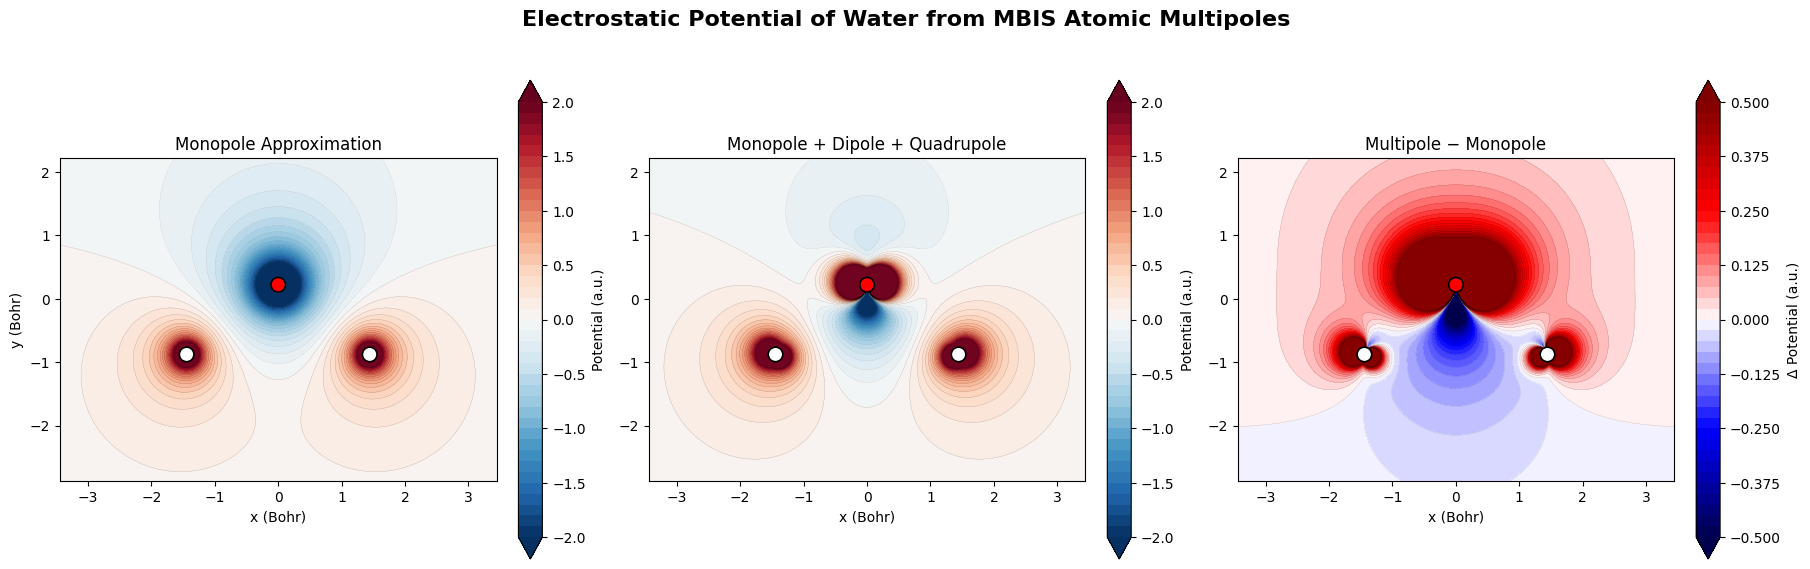

In [46]:
def plot_atoms(ax, atcoords, atnums):
    """Scatter atoms onto an axis using element-based coloring."""
    colors = [ELEMENT_COLORS.get(z, "gray") for z in atnums]
    ax.scatter(
        atcoords[:, 0],
        atcoords[:, 1],
        c=colors,
        edgecolors="black",
        s=ATOM_MARKER_SIZE,
        linewidths=ATOM_EDGE_WIDTH,
        zorder=10,
    )


def plot_potential_panel(
    ax,
    data,
    levels,
    cmap,
    title,
    cbar_label,
    xlabel="x (Bohr)",
    ylabel=None,
):
    """Draw one filled-contour potential panel with atoms overlaid.

    Consolidates the contourf + contour-line + atom-scatter + styling
    logic shared by all three panels of the figure.
    """
    cf = ax.contourf(X, Y, data, levels=levels, cmap=cmap, extend="both")
    ax.contour(
        X, Y, data,
        levels=levels,
        colors="k",
        linewidths=CONTOUR_LINE_WIDTH,
        alpha=CONTOUR_LINE_ALPHA,
    )
    plot_atoms(ax, nb.atcoords, nb.atnums)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.grid(False)

    plt.colorbar(cf, ax=ax, shrink=0.85, label=cbar_label)


# Clip potentials for visualization (see markdown note above)
mono_plot = np.clip(V_mono, -MONO_CLIP, MONO_CLIP)
full_plot = np.clip(V_full, -FULL_CLIP, FULL_CLIP)
diff_plot = np.clip(V_diff, -DIFF_CLIP, DIFF_CLIP)

# Shared levels for panels 1-2; a separate, finer diverging scale for panel 3
shared_levels = np.linspace(-MONO_CLIP, MONO_CLIP, 41)
diff_levels = np.linspace(-DIFF_CLIP, DIFF_CLIP, 41)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
fig.suptitle(
    "Electrostatic Potential of Water from MBIS Atomic Multipoles",
    fontsize=16,
    fontweight="bold",
)

plot_potential_panel(
    axes[0], mono_plot, shared_levels, "RdBu_r",
    title="Monopole Approximation",
    cbar_label="Potential (a.u.)",
    ylabel="y (Bohr)",
)
plot_potential_panel(
    axes[1], full_plot, shared_levels, "RdBu_r",
    title="Monopole + Dipole + Quadrupole",
    cbar_label="Potential (a.u.)",
)
plot_potential_panel(
    axes[2], diff_plot, diff_levels, "seismic",
    title="Multipole \u2212 Monopole",
    cbar_label="\u0394 Potential (a.u.)",
)

plt.savefig(OUTPUT_FIGURE, dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
